## 1. Imports

In [33]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import warnings
from scipy import stats 


from flow_tree_utils import compute_extended_explore_traj, compute_explore_traj, generate_trajs_from_df, generate_flow_tree_from_trajs, plot_flow_tree

warnings.filterwarnings("ignore")
pd.options.mode.chained_assignment = None

## 2. Load data

In [7]:
df = pd.read_csv("data/MLINDIV_train_full.csv")

# load test df
test_df = df[df["eprocs"].str.contains("Test")]

test_df["subj_mean_acc"] = test_df.groupby("Subject")["accuracy"].transform("mean")
test_df["path_mean_acc"] = test_df.groupby(["StartAt", "EndAt"])["accuracy"].transform("mean")

test_df['quartile'] = (
    pd.qcut(test_df['subj_mean_acc'], 4, labels=[1, 2, 3, 4])
)

test_df["path_mean_acc_by_Q"] = test_df.groupby(["StartAt", "EndAt", "quartile"])["accuracy"].transform("mean")

test_df["accuracy"] = test_df["accuracy"].astype(bool)

subject_df = pd.read_csv("data/MLINDIV_subject_info.csv")
subject_df["Subject"] = pd.to_numeric(subject_df["Spatial Neuro ID"], errors="coerce")
subject_df = subject_df[~subject_df["Subject"].isna()]

subject_df["is_man"] = (subject_df["Sex"] == "M")

merged_test_df = pd.merge(test_df, subject_df, on="Subject")
# merged_df[["Sex", "Proportion Correct (new version)", "subject_mean_acc"]]

## 3. Generate all test-path Flow Trees and backbones

In [9]:
def get_heaviest_path(tree, root):    
    # Get all leaves (nodes with degree 1, excluding the root)
    # leaves = [node for node in tree.nodes() if tree.degree(node) == 1 and node != root]
    leaves = [node for node in tree.nodes() if tree.nodes[node].get("color", "white") in ["yellow", "green"]]
    
    def dfs(node, current_path, current_weight):
        nonlocal max_weight, heaviest_path
        
        # If we're at a leaf (degree 1 and not root)
        if node in leaves:
            if current_weight > max_weight:
                max_weight = current_weight
                heaviest_path = current_path.copy()
            return
            
        # Explore all children
        for neighbor in tree.neighbors(node):
            if neighbor not in current_path:  # Avoid cycles
                edge_weight = tree[node][neighbor]['weight']
                current_path.append(neighbor)
                dfs(neighbor, current_path, current_weight + edge_weight)
                current_path.pop()
    
    max_weight = float('-inf')
    heaviest_path = None
    dfs(root, [root], 0)
    
    return heaviest_path, max_weight, [tree[heaviest_path[i]][heaviest_path[i+1]]['weight'] for i in range(len(heaviest_path)-1)]

flow_tree_dict = {}
for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    trajs = generate_trajs_from_df(group)
    G = generate_flow_tree_from_trajs(trajs, END_NODE=end_node)

    # print("Finding backbone for", path)
    backbone_path, max_weight, weights = get_heaviest_path(G, start_node)
    flow_tree_dict[(start_node, end_node)] = {
        "flow_tree": G,
        "acc": group["path_mean_acc"].iloc[0],
        "backbone_path": backbone_path,
        "backbone_weights": weights
        }

## 4. Count women v men using backbone

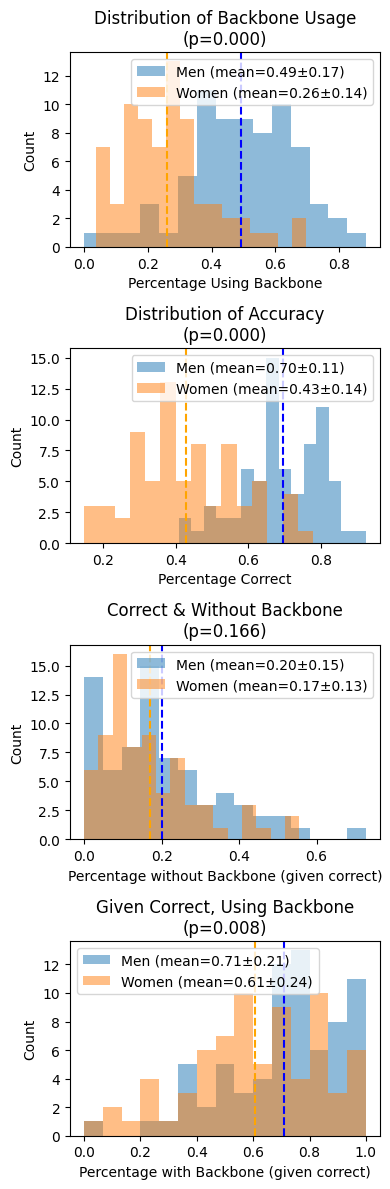

In [59]:
men_using_backbone = []
men_correct = []
men_correct_no_backbone = []
men_correct_with_backbone = []
total_men = []

women_using_backbone = []
women_correct = []
women_correct_no_backbone = []
women_correct_with_backbone = []
total_women = []

for (start_node, end_node), group in merged_test_df.groupby(["StartAt", "EndAt"]):
    men_group = group[group["is_man"]]
    women_group = group[~group["is_man"]]

    correct_men_group = men_group[men_group["accuracy"]]
    correct_women_group = women_group[women_group["accuracy"]]

    total_men.append(len(men_group))
    total_women.append(len(women_group))

    men_correct.append(len(correct_men_group))
    women_correct.append(len(correct_women_group))

    backbone_path = flow_tree_dict[(start_node, end_node)]["backbone_path"][-1]
    
    men_trajs = generate_trajs_from_df(men_group)
    men_used_backbone = [backbone_path == "".join(traj) for traj in men_trajs]
    men_using_backbone.append(men_used_backbone)

    women_trajs = generate_trajs_from_df(women_group)
    women_used_backbone = [backbone_path == "".join(traj) for traj in women_trajs]
    women_using_backbone.append(women_used_backbone)

    # Get correct trajectories using backbone
    correct_men_trajs = generate_trajs_from_df(correct_men_group)
    correct_men_with_backbone = [backbone_path == "".join(traj) for traj in correct_men_trajs]
    men_correct_with_backbone.append(correct_men_with_backbone)

    correct_women_trajs = generate_trajs_from_df(correct_women_group)
    correct_women_with_backbone = [backbone_path == "".join(traj) for traj in correct_women_trajs]
    women_correct_with_backbone.append(correct_women_with_backbone)

    # Get correct trajectories not using backbone
    correct_men_no_backbone = [backbone_path != "".join(traj) for traj in correct_men_trajs]
    men_correct_no_backbone.append(correct_men_no_backbone)

    correct_women_no_backbone = [backbone_path != "".join(traj) for traj in correct_women_trajs]
    women_correct_no_backbone.append(correct_women_no_backbone)

    if len(correct_women_group) != sum(correct_women_no_backbone) + sum(correct_women_with_backbone):
        print(f"Correct women group len: {len(correct_women_group)}")
        print(f"Correct women no backbone len: {sum(correct_women_no_backbone)}")
        print(f"Correct women with backbone len: {sum(correct_women_with_backbone)}")
        print(f"Correct women trajs len: {len(correct_women_trajs)}")
        print("AH FUCK")

# Calculate percentages
men_backbone_pct = [sum(x)/total for x, total in zip(men_using_backbone, total_men)]
women_backbone_pct = [sum(x)/total for x, total in zip(women_using_backbone, total_women)]

men_correct_pct = [correct/total for correct, total in zip(men_correct, total_men)]
women_correct_pct = [correct/total for correct, total in zip(women_correct, total_women)]

men_correct_no_backbone_pct = [sum(x)/total for x, total in zip(men_correct_no_backbone, total_men)]
women_correct_no_backbone_pct = [sum(x)/total for x, total in zip(women_correct_no_backbone, total_women)]

men_correct_with_backbone_pct = [sum(x)/total for x, total in zip(men_correct_with_backbone, men_correct)]
women_correct_with_backbone_pct = [sum(x)/total for x, total in zip(women_correct_with_backbone, women_correct)]

# Create figure with four subplots
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(4, 12))

# Plot backbone usage distributions and test significance
men_backbone_mean = np.mean(men_backbone_pct)
men_backbone_std = np.std(men_backbone_pct)
women_backbone_mean = np.mean(women_backbone_pct)
women_backbone_std = np.std(women_backbone_pct)
backbone_ttest = stats.ttest_ind(men_backbone_pct, women_backbone_pct)
ax1.hist(men_backbone_pct, alpha=0.5, label=f'Men (mean={men_backbone_mean:.2f}±{men_backbone_std:.2f})', bins=15)
ax1.hist(women_backbone_pct, alpha=0.5, label=f'Women (mean={women_backbone_mean:.2f}±{women_backbone_std:.2f})', bins=15)
ax1.axvline(men_backbone_mean, color='blue', linestyle='--')
ax1.axvline(women_backbone_mean, color='orange', linestyle='--')
ax1.set_title(f'Distribution of Backbone Usage\n(p={backbone_ttest.pvalue:.3f})')
ax1.set_xlabel('Percentage Using Backbone')
ax1.set_ylabel('Count')
ax1.legend()

# Plot accuracy distributions and test significance
men_correct_mean = np.mean(men_correct_pct)
men_correct_std = np.std(men_correct_pct)
women_correct_mean = np.mean(women_correct_pct)
women_correct_std = np.std(women_correct_pct)
accuracy_ttest = stats.ttest_ind(men_correct_pct, women_correct_pct)
ax2.hist(men_correct_pct, alpha=0.5, label=f'Men (mean={men_correct_mean:.2f}±{men_correct_std:.2f})', bins=15)
ax2.hist(women_correct_pct, alpha=0.5, label=f'Women (mean={women_correct_mean:.2f}±{women_correct_std:.2f})', bins=15)
ax2.axvline(men_correct_mean, color='blue', linestyle='--')
ax2.axvline(women_correct_mean, color='orange', linestyle='--')
ax2.set_title(f'Distribution of Accuracy\n(p={accuracy_ttest.pvalue:.3f})')
ax2.set_xlabel('Percentage Correct')
ax2.set_ylabel('Count')
ax2.legend()

# Plot correct but no backbone distributions and test significance
men_no_backbone_mean = np.mean(men_correct_no_backbone_pct)
men_no_backbone_std = np.std(men_correct_no_backbone_pct)
women_no_backbone_mean = np.mean(women_correct_no_backbone_pct)
women_no_backbone_std = np.std(women_correct_no_backbone_pct)
no_backbone_ttest = stats.ttest_ind(men_correct_no_backbone_pct, women_correct_no_backbone_pct)
ax3.hist(men_correct_no_backbone_pct, alpha=0.5, label=f'Men (mean={men_no_backbone_mean:.2f}±{men_no_backbone_std:.2f})', bins=15)
ax3.hist(women_correct_no_backbone_pct, alpha=0.5, label=f'Women (mean={women_no_backbone_mean:.2f}±{women_no_backbone_std:.2f})', bins=15)
ax3.axvline(men_no_backbone_mean, color='blue', linestyle='--')
ax3.axvline(women_no_backbone_mean, color='orange', linestyle='--')
ax3.set_title(f'Correct & Without Backbone\n(p={no_backbone_ttest.pvalue:.3f})')
ax3.set_xlabel('Percentage without Backbone (given correct)')
ax3.set_ylabel('Count')
ax3.legend()

# Plot correct with backbone distributions and test significance
men_with_backbone_mean = np.mean(men_correct_with_backbone_pct)
men_with_backbone_std = np.std(men_correct_with_backbone_pct)
women_with_backbone_mean = np.mean(women_correct_with_backbone_pct)
women_with_backbone_std = np.std(women_correct_with_backbone_pct)
with_backbone_ttest = stats.ttest_ind(men_correct_with_backbone_pct, women_correct_with_backbone_pct)
ax4.hist(men_correct_with_backbone_pct, alpha=0.5, label=f'Men (mean={men_with_backbone_mean:.2f}±{men_with_backbone_std:.2f})', bins=15)
ax4.hist(women_correct_with_backbone_pct, alpha=0.5, label=f'Women (mean={women_with_backbone_mean:.2f}±{women_with_backbone_std:.2f})', bins=15)
ax4.axvline(men_with_backbone_mean, color='blue', linestyle='--')
ax4.axvline(women_with_backbone_mean, color='orange', linestyle='--')
ax4.set_title(f'Given Correct, Using Backbone\n(p={with_backbone_ttest.pvalue:.3f})')
ax4.set_xlabel('Percentage with Backbone (given correct)')
ax4.set_ylabel('Count')
ax4.legend()

plt.tight_layout()
plt.show()


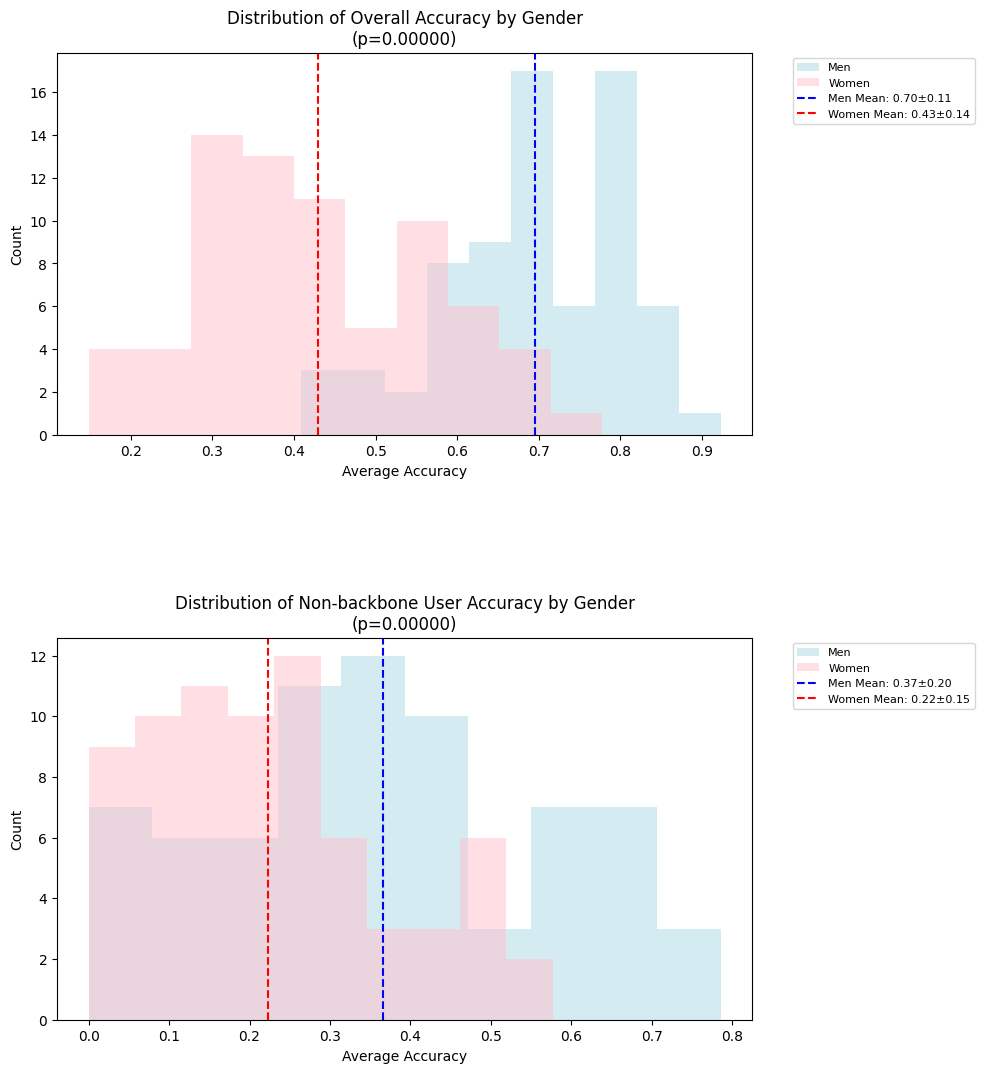

In [39]:
# Calculate accuracy for men and women not using backbone for each path
men_non_backbone_accuracies = []
women_non_backbone_accuracies = []
men_accuracies = []
women_accuracies = []

for (start_node, end_node), group in merged_test_df.groupby(["StartAt", "EndAt"]):
    backbone_path = flow_tree_dict[(start_node, end_node)]["backbone_path"][-1]
    
    # Get men's and women's data separately
    men_group = group[group["is_man"]]
    women_group = group[~group["is_man"]]
    
    # Get overall accuracies
    if len(men_group) > 0:
        men_accuracies.append(men_group["accuracy"].mean())
    if len(women_group) > 0:
        women_accuracies.append(women_group["accuracy"].mean())
    
    # Process men's data for non-backbone
    men_trajs = generate_trajs_from_df(men_group)
    men_used_backbone = [backbone_path == "".join(traj) for traj in men_trajs]
    men_non_backbone_mask = ~np.array(men_used_backbone, dtype=bool)
    men_non_backbone_users = men_group[men_non_backbone_mask]
    
    if len(men_non_backbone_users) > 0:
        men_non_backbone_accuracies.append(men_non_backbone_users["accuracy"].mean())
        
    # Process women's data for non-backbone
    women_trajs = generate_trajs_from_df(women_group)
    women_used_backbone = [backbone_path == "".join(traj) for traj in women_trajs]
    women_non_backbone_mask = ~np.array(women_used_backbone, dtype=bool)
    women_non_backbone_users = women_group[women_non_backbone_mask]
    
    if len(women_non_backbone_users) > 0:
        women_non_backbone_accuracies.append(women_non_backbone_users["accuracy"].mean())

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4, 6))

# Calculate means, stds and run t-tests
men_mean = np.mean(men_accuracies)
men_std = np.std(men_accuracies)
women_mean = np.mean(women_accuracies)
women_std = np.std(women_accuracies)
overall_ttest = stats.ttest_ind(men_accuracies, women_accuracies)

men_mean_acc = np.mean(men_non_backbone_accuracies)
men_std_acc = np.std(men_non_backbone_accuracies)
women_mean_acc = np.mean(women_non_backbone_accuracies)
women_std_acc = np.std(women_non_backbone_accuracies)
nonbackbone_ttest = stats.ttest_ind(men_non_backbone_accuracies, women_non_backbone_accuracies)

# Plot overall accuracies
ax1.hist(men_accuracies, bins=10, alpha=0.5, color='lightblue', label='Men')
ax1.hist(women_accuracies, bins=10, alpha=0.5, color='pink', label='Women')
ax1.set_title(f'Distribution of Overall Accuracy by Gender\n(p={overall_ttest.pvalue:.5f})')
ax1.set_xlabel('Average Accuracy')
ax1.set_ylabel('Count')

# Add mean lines for overall accuracies
ax1.axvline(men_mean, color='blue', linestyle='--', label=f'Men Mean: {men_mean:.2f}±{men_std:.2f}')
ax1.axvline(women_mean, color='red', linestyle='--', label=f'Women Mean: {women_mean:.2f}±{women_std:.2f}')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', prop={'size': 8})

# Plot non-backbone accuracies
ax2.hist(men_non_backbone_accuracies, bins=10, alpha=0.5, color='lightblue', label='Men')
ax2.hist(women_non_backbone_accuracies, bins=10, alpha=0.5, color='pink', label='Women')
ax2.set_title(f'Distribution of Non-backbone User Accuracy by Gender\n(p={nonbackbone_ttest.pvalue:.5f})')
ax2.set_xlabel('Average Accuracy')
ax2.set_ylabel('Count')

# Add mean lines for non-backbone accuracies
ax2.axvline(men_mean_acc, color='blue', linestyle='--', label=f'Men Mean: {men_mean_acc:.2f}±{men_std_acc:.2f}')
ax2.axvline(women_mean_acc, color='red', linestyle='--', label=f'Women Mean: {women_mean_acc:.2f}±{women_std_acc:.2f}')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', prop={'size': 8})

plt.tight_layout()
plt.gcf().set_size_inches(10, 12)  # Make figure larger
plt.subplots_adjust(right=0.85)    # Adjust right margin to prevent legend cutoff
plt.show()

In [28]:
# Calculate overall accuracy for men and women
men_overall = merged_test_df[merged_test_df['is_man']]['accuracy'].mean()
women_overall = merged_test_df[~merged_test_df['is_man']]['accuracy'].mean()

print(f"Overall accuracy for men: {men_overall:.3f}")
print(f"Overall accuracy for women: {women_overall:.3f}")


Overall accuracy for men: 0.695
Overall accuracy for women: 0.434
